WEEK 1 : MILESTONE 1

In [16]:
import os
from pycocotools.coco import COCO

base_dir = r'D:\infosys' 
data_dir = os.path.join(base_dir, 'dataset', 'coco2017')
ann_file = os.path.join(data_dir, 'annotations', 'instances_train2017.json')
img_dir = os.path.join(data_dir, 'train2017')

if os.path.exists(ann_file):
    print("Success! Annotation file found.")
  
    coco = COCO(ann_file)
else:
    print("Error: File still not found.")
    print(f"I am looking for: {ann_file}")
   
    print("Contents of dataset folder:", os.listdir(os.path.join(base_dir, 'dataset')))

Success! Annotation file found.
loading annotations into memory...
Done (t=9.25s)
creating index...
index created!


WEEK 2 : MILESTONE 1

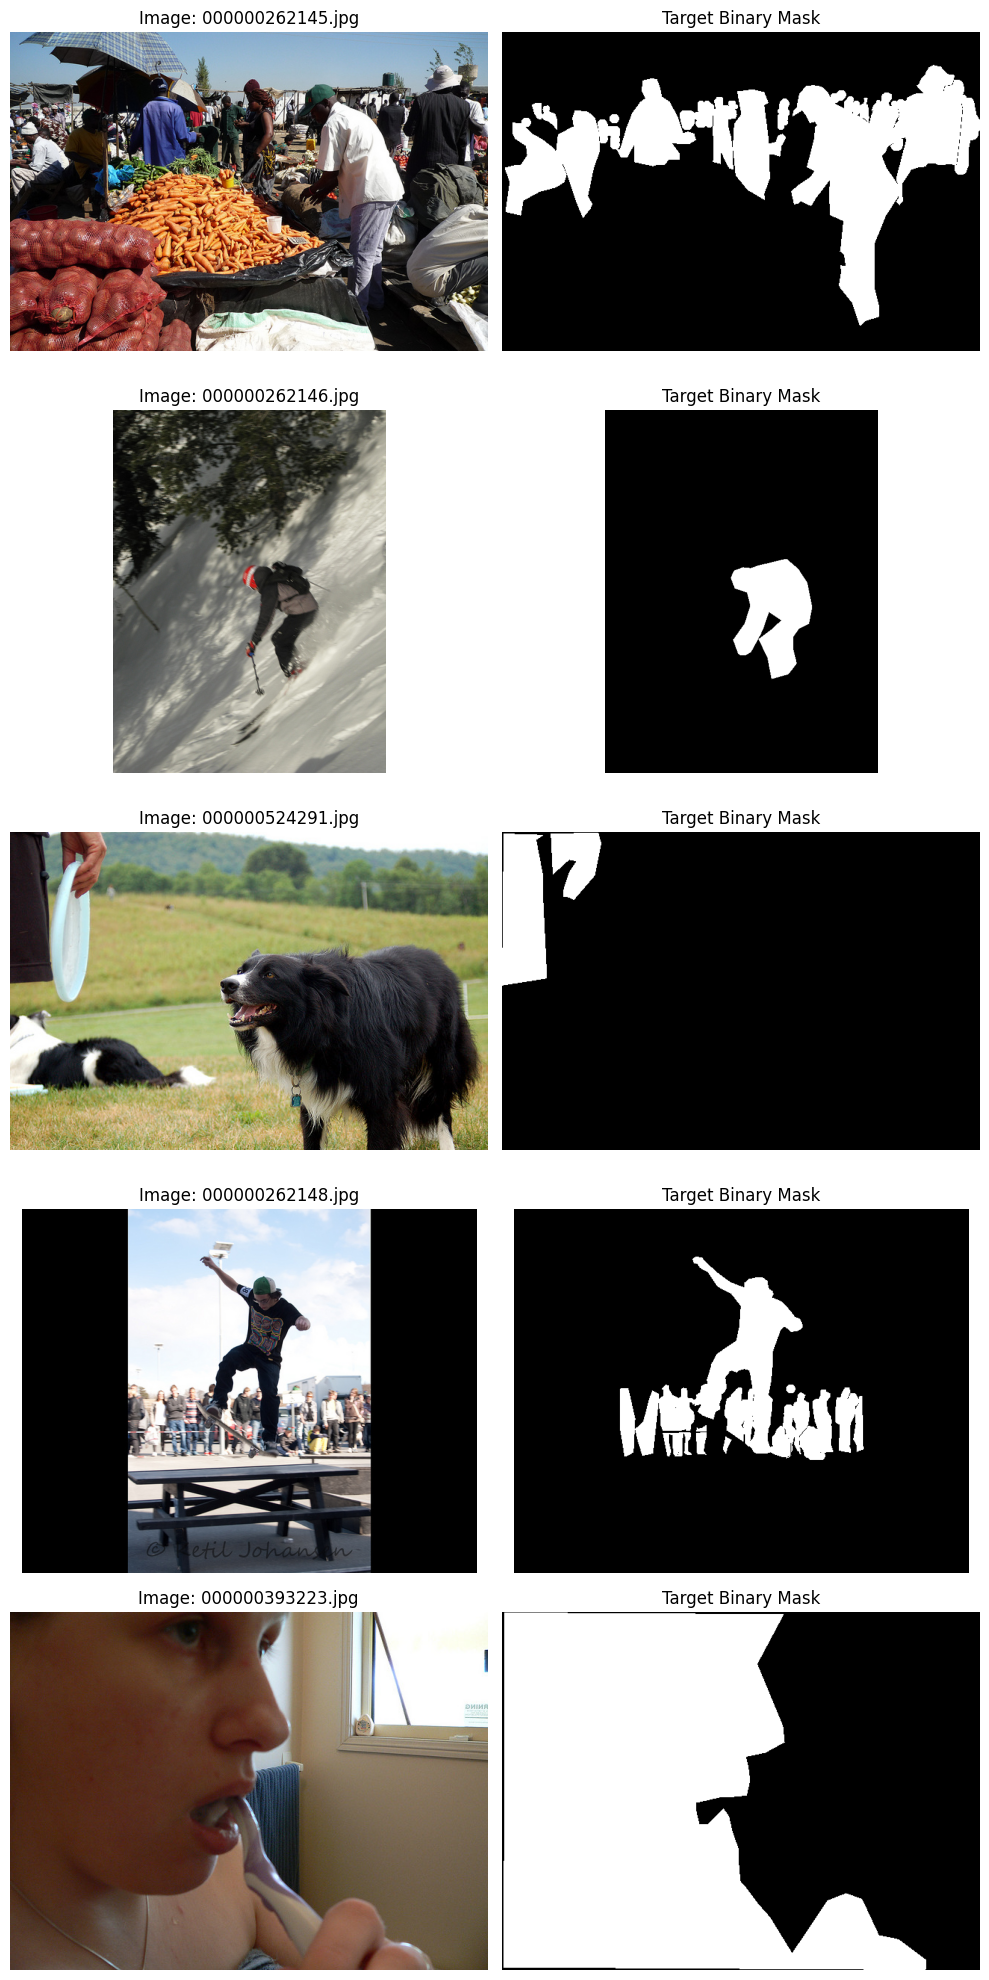

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

cat_ids = coco.getCatIds(catNms=['person'])
img_ids = coco.getImgIds(catIds=cat_ids)

sample_img_ids = img_ids[:5]
images_info = coco.loadImgs(sample_img_ids)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i, img_info in enumerate(images_info):
   
    img_path = os.path.join(img_dir, img_info['file_name'])
    image = Image.open(img_path)
    
    ann_ids = coco.getAnnIds(imgIds=img_info['id'], catIds=cat_ids, iscrowd=None)
    anns = coco.loadAnns(ann_ids)
    
    mask = np.zeros((img_info['height'], img_info['width']))
    for ann in anns:
       
        mask = np.maximum(mask, coco.annToMask(ann))
    
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"Image: {img_info['file_name']}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title("Target Binary Mask")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [18]:
import tensorflow as tf
import numpy as np
from PIL import Image
import os
from pycocotools.coco import COCO

def preprocess_data(image, mask, target_size=(256, 256)):
 
    image = tf.image.resize(image, target_size)
    mask = tf.image.resize(mask, target_size, method='nearest')
    
    image = tf.cast(image, tf.float32) / 255.0
    
    mask = tf.cast(mask > 0, tf.float32)
    
    return image, mask

def load_image_and_mask(image_id):
    """
    Loads an image and generates its binary mask from COCO annotations.
    """
    image_id = int(image_id.numpy())
    
    img_info = coco.loadImgs(image_id)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])
    
    image = Image.open(img_path).convert('RGB')
    image = np.array(image)
    
    ann_ids = coco.getAnnIds(imgIds=image_id, catIds=cat_ids, iscrowd=None)
    anns = coco.loadAnns(ann_ids)
    
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))
    
    mask = np.expand_dims(mask, axis=-1)
    
    return image, mask

def tf_load_data(image_id):
    [image, mask] = tf.py_function(load_image_and_mask, [image_id], [tf.uint8, tf.uint8])
    image.set_shape([None, None, 3])
    mask.set_shape([None, None, 1])
    return image, mask

def get_dataset(ids, batch_size=16):

    dataset = tf.data.Dataset.from_tensor_slices(ids)
    
    dataset = dataset.map(tf_load_data, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

person_img_ids = coco.getImgIds(catIds=cat_ids)
print(f"Total Images in Pipeline: {len(person_img_ids)}")

train_dataset = get_dataset(person_img_ids, batch_size=16)

print("Attempting to load one batch...")
for images, masks in train_dataset.take(1):
    print(f"Success! Batch Image Shape: {images.shape}")
    print(f"Success! Batch Mask Shape: {masks.shape}")  

Total Images in Pipeline: 64115
Attempting to load one batch...
Success! Batch Image Shape: (16, 256, 256, 3)
Success! Batch Mask Shape: (16, 256, 256, 1)


WEEK 3 : MILESTONE 2

In [1]:
import os
import cv2
import numpy as np
import random
import shutil
from pycocotools.coco import COCO

def setup_train_val_test_split(dataset_root, output_root, data_type='val2017', total_images=5000):
    print("Starting the dataset split... Please wait.")
    ann_file = os.path.join(dataset_root, 'annotations', f'instances_{data_type}.json')
    source_img_dir = os.path.join(dataset_root, data_type)
    
    coco = COCO(ann_file)
    img_ids = coco.getImgIds()[:total_images]
    random.seed(42)
    random.shuffle(img_ids)
    
    train_split = int(total_images * 0.70)
    val_split = train_split + int(total_images * 0.15)
    
    splits = {
        'train': img_ids[:train_split],
        'val': img_ids[train_split:val_split],
        'test': img_ids[val_split:]
    }

    for split_name, ids in splits.items():
        print(f"\nBuilding {split_name} folder...")
        split_img_dir = os.path.join(output_root, split_name, 'images')
        split_mask_dir = os.path.join(output_root, split_name, 'masks')
        os.makedirs(split_img_dir, exist_ok=True)
        os.makedirs(split_mask_dir, exist_ok=True)
        
        saved_count = 0
        for img_id in ids:
            img_info = coco.loadImgs(img_id)[0]
            filename = img_info['file_name']
            
            src_img_path = os.path.join(source_img_dir, filename)
            dst_img_path = os.path.join(split_img_dir, filename)
            
            if not os.path.exists(dst_img_path):
                shutil.copy(src_img_path, dst_img_path)
            
            mask_filename = filename.replace('.jpg', '.png')
            dst_mask_path = os.path.join(split_mask_dir, mask_filename)
            
            if not os.path.exists(dst_mask_path):
                ann_ids = coco.getAnnIds(imgIds=img_id)
                anns = coco.loadAnns(ann_ids)
                
                mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
                for ann in anns:
                    mask = np.maximum(mask, coco.annToMask(ann))
                
                mask = mask * 255 
                cv2.imwrite(dst_mask_path, mask)
            
            saved_count += 1
            if saved_count % 500 == 0:
                print(f"  -> Processed {saved_count} / {len(ids)} files...")

    print(f"\n✅ Dataset splitting complete! Folders are ready at: {output_root}")

# Run the setup!
DATASET_ROOT = r'D:\infosys\dataset\coco2017'
PROJECT_DATASET = r'D:\infosys\dataset\My_Segmentation_Project'
setup_train_val_test_split(dataset_root=DATASET_ROOT, output_root=PROJECT_DATASET)

Starting the dataset split... Please wait.
loading annotations into memory...
Done (t=0.39s)
creating index...
index created!

Building train folder...
  -> Processed 500 / 3500 files...
  -> Processed 1000 / 3500 files...
  -> Processed 1500 / 3500 files...
  -> Processed 2000 / 3500 files...
  -> Processed 2500 / 3500 files...
  -> Processed 3000 / 3500 files...
  -> Processed 3500 / 3500 files...

Building val folder...
  -> Processed 500 / 750 files...

Building test folder...
  -> Processed 500 / 750 files...

✅ Dataset splitting complete! Folders are ready at: D:\infosys\dataset\My_Segmentation_Project


In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Point these to the new split folders you just created!
PROJECT_DIR = r'D:\infosys\dataset\My_Segmentation_Project'
TRAIN_IMG_DIR = os.path.join(PROJECT_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(PROJECT_DIR, 'train', 'masks')
VAL_IMG_DIR = os.path.join(PROJECT_DIR, 'val', 'images')
VAL_MASK_DIR = os.path.join(PROJECT_DIR, 'val', 'masks')

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

In [3]:
class SegmentationGenerator(tf.keras.utils.Sequence):
    def __init__(self, img_dir, mask_dir, batch_size, img_size):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.filenames = os.listdir(img_dir)

    def __len__(self):
        return int(np.ceil(len(self.filenames) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_files = self.filenames[idx * self.batch_size : (idx + 1) * self.batch_size]
        
        images = []
        masks = []
        
        for filename in batch_files:
            # Load and preprocess image
            img_path = os.path.join(self.img_dir, filename)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size) / 255.0
            
            # Load and preprocess mask
            mask_path = os.path.join(self.mask_dir, filename.replace('.jpg', '.png'))
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, self.img_size) / 255.0
            mask = np.expand_dims(mask, axis=-1) # Add channel dimension
            
            images.append(img)
            masks.append(mask)
            
        return np.array(images), np.array(masks)

# Initialize the generators
train_gen = SegmentationGenerator(TRAIN_IMG_DIR, TRAIN_MASK_DIR, BATCH_SIZE, IMG_SIZE)
val_gen = SegmentationGenerator(VAL_IMG_DIR, VAL_MASK_DIR, BATCH_SIZE, IMG_SIZE)
print("Data Generators Ready!")

Data Generators Ready!


In [4]:
def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder (Downsampling)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    b = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)

    # Decoder (Upsampling)
    u1 = layers.UpSampling2D((2, 2))(b)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(layers.concatenate([u1, c2]))

    u2 = layers.UpSampling2D((2, 2))(c3)
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(layers.concatenate([u2, c1]))

    # Output Layer (1 channel for binary mask, Sigmoid activation for probabilities)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │         33 │ conv2d_4[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 231,617 (904.75 KB)

 Trainable params: 231,617 (904.75 KB)

 Non-trainable params: 0 (0.00 B)

Starting initial training...


d:\infosys\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.7036 - loss: 0.5705 - val_accuracy: 0.7296 - val_loss: 0.5238
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.7195 - loss: 0.5399 - val_accuracy: 0.7372 - val_loss: 0.5166
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 131s 599ms/step - accuracy: 0.7272 - loss: 0.5264 - val_accuracy: 0.7427 - val_loss: 0.5033
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 112s 509ms/step - accuracy: 0.7325 - loss: 0.5224 - val_accuracy: 0.7434 - val_loss: 0.5035
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 117s 534ms/step - accuracy: 0.7368 - loss: 0.5157 - val_accuracy: 0.7517 - val_loss: 0.4980


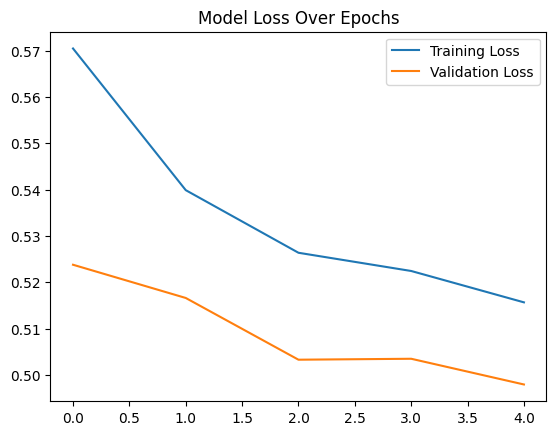

In [5]:
print("Starting initial training...")
# Training for just 5 epochs for the initial run to see if it learns
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5 
)

# Plot the training metrics
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


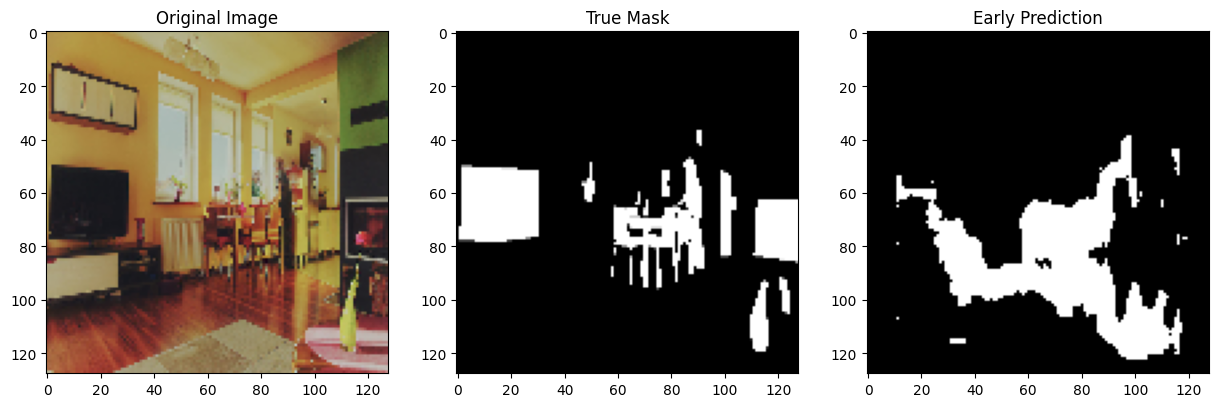

In [6]:
# Grab one batch of validation data
val_images, val_masks = val_gen[0]

# Generate predictions
preds = model.predict(val_images)

# Visualize the first image in the batch
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(val_images[0])

plt.subplot(1, 3, 2)
plt.title("True Mask")
plt.imshow(val_masks[0].squeeze(), cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Early Prediction")
plt.imshow((preds[0].squeeze() > 0.5).astype(np.uint8), cmap='gray')
plt.show()

WEEK 4 : MILESTONE 2

In [7]:
def calculate_iou(y_true, y_pred):
    y_true_bin = (y_true > 0.5).astype(np.uint8)
    y_pred_bin = (y_pred > 0.5).astype(np.uint8)
    intersection = np.logical_and(y_true_bin, y_pred_bin).sum()
    union = np.logical_or(y_true_bin, y_pred_bin).sum()
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

# Calculate Average IoU on a validation batch
batch_iou = []
for i in range(len(val_images)):
    iou = calculate_iou(val_masks[i], preds[i])
    batch_iou.append(iou)

print(f"Average Validation IoU for Batch: {np.mean(batch_iou):.4f}")

Average Validation IoU for Batch: 0.2555


In [8]:
# 1. Data Augmentation Pipeline
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.1),
])

# 2. Update the Generator to use Augmentation
class AugmentedGenerator(SegmentationGenerator):
    def __getitem__(self, idx):
        images, masks = super().__getitem__(idx)
        # Apply the same random augmentation to BOTH image and mask
        # so they stay perfectly aligned!
        seed = np.random.randint(0, 1000)
        aug_images = data_augmentation(images, training=True, seed=seed)
        aug_masks = data_augmentation(masks, training=True, seed=seed)
        return aug_images, aug_masks

aug_train_gen = AugmentedGenerator(TRAIN_IMG_DIR, TRAIN_MASK_DIR, BATCH_SIZE, IMG_SIZE)

# 3. Adjust Hyperparameters (Lower the learning rate for fine-tuning)
fine_tune_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4) # Standard is 1e-3
model.compile(optimizer=fine_tune_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

print("Ready for fine-tuning with Augmented Data and adjusted Learning Rate!")

Ready for fine-tuning with Augmented Data and adjusted Learning Rate!


In [18]:
print("Starting fine-tuning process...")
# Train for more epochs using the augmented data
fine_tune_history = model.fit(
    aug_train_gen,
    validation_data=val_gen, # Never augment validation data!
    epochs=10
)

# Save your final, fine-tuned model
model.save(os.path.join(PROJECT_DIR, 'final_segmentation_model.keras'))
print("Fine-tuning complete and model saved!")

Starting fine-tuning process...


d:\infosys\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.6613 - loss: 0.6159 - val_accuracy: 0.7112 - val_loss: 0.5554
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 103s 471ms/step - accuracy: 0.6738 - loss: 0.5889 - val_accuracy: 0.7162 - val_loss: 0.5333
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 97s 443ms/step - accuracy: 0.6766 - loss: 0.5811 - val_accuracy: 0.7158 - val_loss: 0.5339
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 97s 444ms/step - accuracy: 0.6773 - loss: 0.5806 - val_accuracy: 0.7245 - val_loss: 0.5370
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 96s 440ms/step - accuracy: 0.6776 - loss: 0.5783 - val_accuracy: 0.7270 - val_loss: 0.5483
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 481ms/step - accuracy: 0.6781 - loss: 0.5768 - val_accuracy: 0.7155 - val_loss: 0.5376
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 102s 467ms/step - accuracy: 0.6789 - loss: 0.5772 - val_accuracy: 0.7213 - val_loss: 0.5251
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 634s 3s/step - accuracy: 0.6795 - loss: 0.

Loading a batch of validation data to test fine-tuned model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


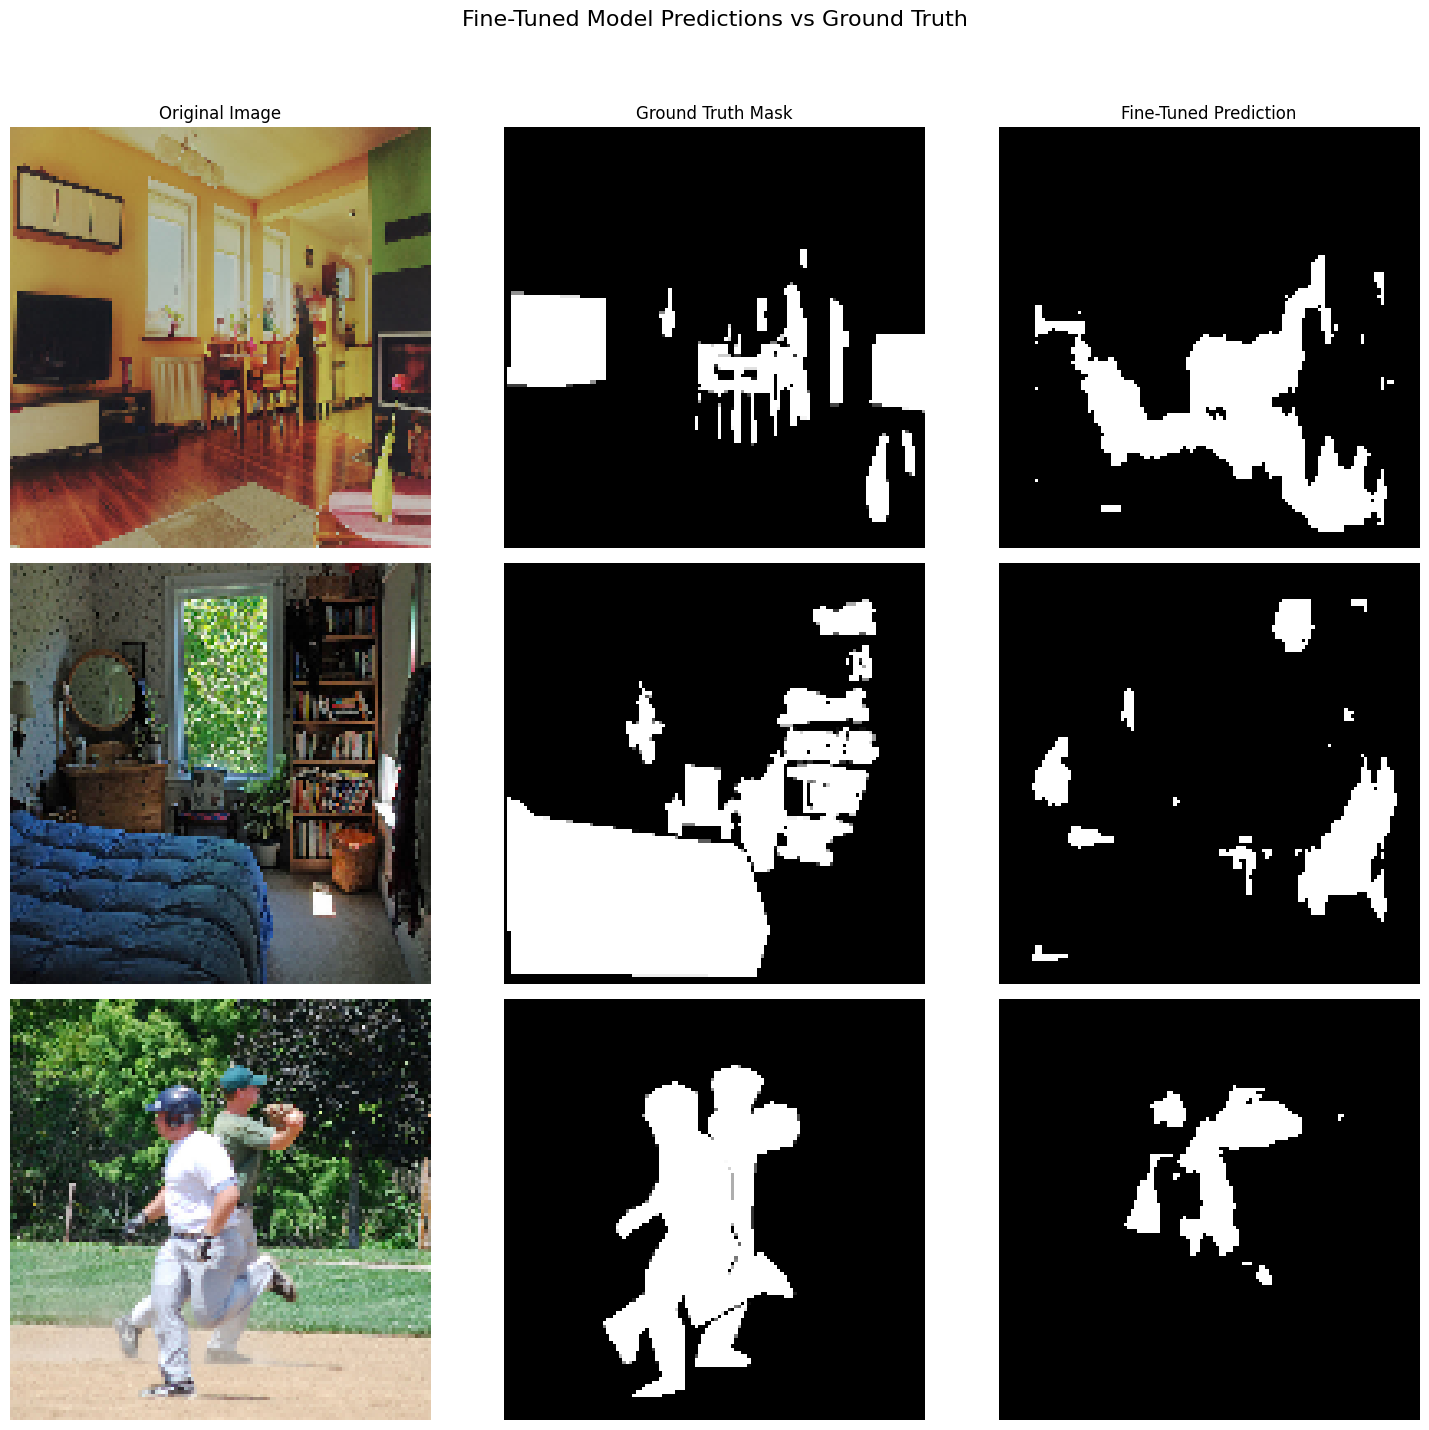

Visualization complete.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

print("Loading a batch of validation data to test fine-tuned model...")
# Grab the very first batch of validation data (val_images and val_masks)
# Make sure 'val_gen' was already created in Cell 2
val_images, val_masks = val_gen[0]

# Generate predictions using the now fine-tuned model
# (Note: 'model' in memory now has the updated weights from Cell 8)
ft_preds = model.predict(val_images)

# We will visualize the first three images in the batch to see the improvement
num_samples = 3

plt.figure(figsize=(15, 5 * num_samples))
plt.suptitle("Fine-Tuned Model Predictions vs Ground Truth", fontsize=16)

for i in range(num_samples):
    # 1. Original RGB Image
    plt.subplot(num_samples, 3, i * 3 + 1)
    if i == 0: plt.title("Original Image")
    plt.imshow(val_images[i])
    plt.axis('off')

    # 2. Perfect Ground-Truth Mask
    plt.subplot(num_samples, 3, i * 3 + 2)
    if i == 0: plt.title("Ground Truth Mask")
    plt.imshow(val_masks[i].squeeze(), cmap='gray')
    plt.axis('off')

    # 3. Model's Fine-Tuned Prediction
    plt.subplot(num_samples, 3, i * 3 + 3)
    if i == 0: plt.title("Fine-Tuned Prediction")
    # We apply a 0.5 threshold to turn probabilities into a solid black/white mask
    binary_pred = (ft_preds[i].squeeze() > 0.5).astype(np.uint8)
    plt.imshow(binary_pred, cmap='gray')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit title
plt.show()

print("Visualization complete.")

WEEK 5 : MILESTONE 3

Applying morphological post-processing to clean the mask...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


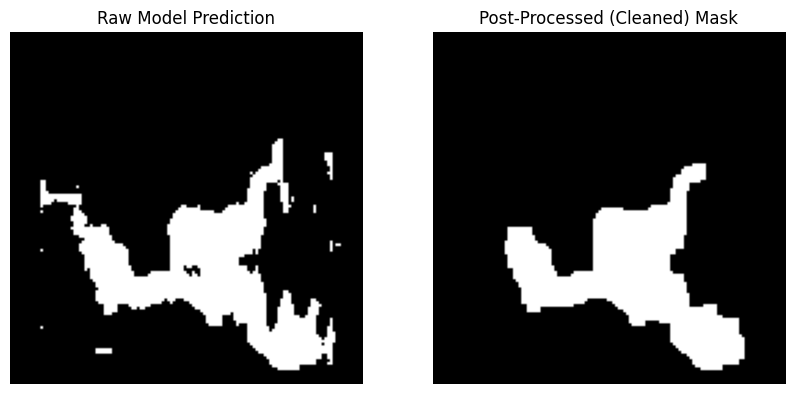

Post-processing complete. Notice how the edges are smoother and noise is reduced!


In [10]:
# Cell 10: Post-Processing for Cleaner Masks
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Applying morphological post-processing to clean the mask...")

# 1. Grab a prediction from your fine-tuned model (from Cell 8/9)
val_images, val_masks = val_gen[0]
preds = model.predict(val_images)

# Convert the first prediction to a strict 0 or 1 binary mask
raw_mask = (preds[0].squeeze() > 0.5).astype(np.uint8)

# 2. Define a mathematical "kernel" (a 5x5 pixel block) to sweep over the image
kernel = np.ones((5,5), np.uint8)

# 3. Apply Morphological Opening (Removes small white noise in the background)
cleaned_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)

# 4. Apply Morphological Closing (Fills in small black holes inside the subject)
cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)

# 5. Visualize the difference!
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Raw Model Prediction")
plt.imshow(raw_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Post-Processed (Cleaned) Mask")
plt.imshow(cleaned_mask, cmap='gray')
plt.axis('off')

plt.show()
print("Post-processing complete. Notice how the edges are smoother and noise is reduced!")

In [11]:
# Cell 11: Exploring Advanced Architecture (MobileNet-UNet)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

def build_transfer_unet(input_shape=(128, 128, 3)):
    # 1. Load the pre-trained MobileNetV2 as our Encoder
    # 'include_top=False' means we chop off its original classification head
    # 'weights=imagenet' loads the pre-trained brain
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    
    # Freeze the base model so we don't destroy its pre-trained knowledge
    base_model.trainable = False 

    # 2. Set the input and grab the bottleneck (the deepest feature map)
    inputs = base_model.input
    x = base_model.output # This is the compressed image data

    # 3. Build a simple Decoder to scale the image back up to 128x128
    # MobileNetV2 shrinks the image by a factor of 32 (down to 4x4), so we upsample 5 times
    for filters in [64, 32, 16, 8, 4]:
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same')(x)

    # 4. Final Output Layer for the binary mask
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)

    transfer_model = models.Model(inputs, outputs)
    return transfer_model

# Build and compile our new advanced architecture
advanced_model = build_transfer_unet()
advanced_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Advanced Transfer Learning U-Net Ready!")
# advanced_model.summary() # Uncomment if you want to see the massive layer list!

Advanced Transfer Learning U-Net Ready!


Configuring advanced training strategies...
Training the Advanced MobileNet-UNet...
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6561 - loss: 0.5841
Epoch 1: val_loss improved from None to 0.50746, saving model to D:\infosys\dataset\My_Segmentation_Project\advanced_mobilenet_unet.keras

Epoch 1: finished saving model to D:\infosys\dataset\My_Segmentation_Project\advanced_mobilenet_unet.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 45s 186ms/step - accuracy: 0.6725 - loss: 0.5523 - val_accuracy: 0.7555 - val_loss: 0.5075
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7214 - loss: 0.5286
Epoch 2: val_loss improved from 0.50746 to 0.50070, saving model to D:\infosys\dataset\My_Segmentation_Project\advanced_mobilenet_unet.keras

Epoch 2: finished saving model to D:\infosys\dataset\My_Segmentation_Project\advanced_mobilenet_unet.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 38s 176ms/step - accuracy: 0.7219 - loss: 0.5253 - val_accuracy: 0.7680 - val_loss: 0.5007
Epoch

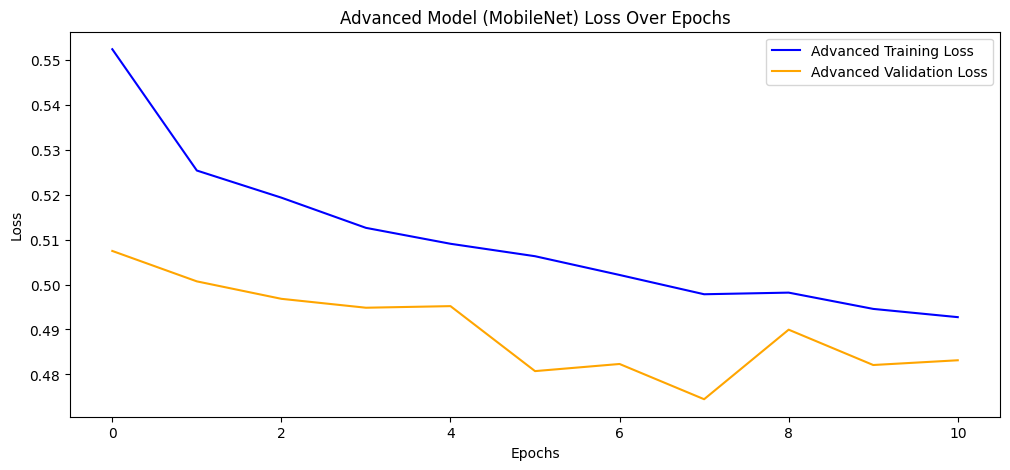


✅ Week 5 Complete: Advanced architecture trained and compared!


In [12]:
# Cell 12: Advanced Training Strategies & Variant Comparison
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
import matplotlib.pyplot as plt

print("Configuring advanced training strategies...")

# 1. Early Stopping: Stop training if the validation loss stops improving
early_stopper = EarlyStopping(
    monitor='val_loss', 
    patience=3,                 # Wait for 3 epochs of no improvement before stopping
    restore_best_weights=True,  # Automatically rewind to the exact best weights!
    verbose=1
)

# 2. Model Checkpoint: Automatically save the best version of this new model
advanced_model_path = os.path.join(PROJECT_DIR, 'advanced_mobilenet_unet.keras')
checkpoint = ModelCheckpoint(
    filepath=advanced_model_path,
    monitor='val_loss',
    save_best_only=True,        # Only overwrite the file if the model actually got better
    verbose=1
)

print("Training the Advanced MobileNet-UNet...")
# 3. Train the model! We use the augmented generator (aug_train_gen) from Week 4.
# We can safely set epochs=15 because Early Stopping will protect us from overfitting.
advanced_history = advanced_model.fit(
    aug_train_gen,
    validation_data=val_gen,
    epochs=15, 
    callbacks=[early_stopper, checkpoint]
)

# 4. Plot the performance to document and compare findings
plt.figure(figsize=(12, 5))
plt.plot(advanced_history.history['loss'], label='Advanced Training Loss', color='blue')
plt.plot(advanced_history.history['val_loss'], label='Advanced Validation Loss', color='orange')
plt.title('Advanced Model (MobileNet) Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("\n✅ Week 5 Complete: Advanced architecture trained and compared!")

WEEK 6 : Milestone 3

In [1]:
# ---------------------------------------------------------
# QUICK START CELL: Run this to skip training entirely!
# ---------------------------------------------------------
import tensorflow as tf
import os

PROJECT_DIR = r'D:\infosys\dataset\My_Segmentation_Project'
saved_model_path = os.path.join(PROJECT_DIR, 'final_segmentation_model.keras')

print("Loading pre-trained model from hard drive...")

# This one line brings your fully trained model back into RAM in 2 seconds!
advanced_model = tf.keras.models.load_model(saved_model_path)

print("✅ Model loaded successfully! You can jump straight to Cell 13 (Inference).")

Loading pre-trained model from hard drive...
✅ Model loaded successfully! You can jump straight to Cell 13 (Inference).


Processing new unseen image: C:\Users\Sai\Downloads\giraffes.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
✅ Success! Subject isolated and saved as: C:\Users\Sai\Downloads\final_isolated_giraffe.png


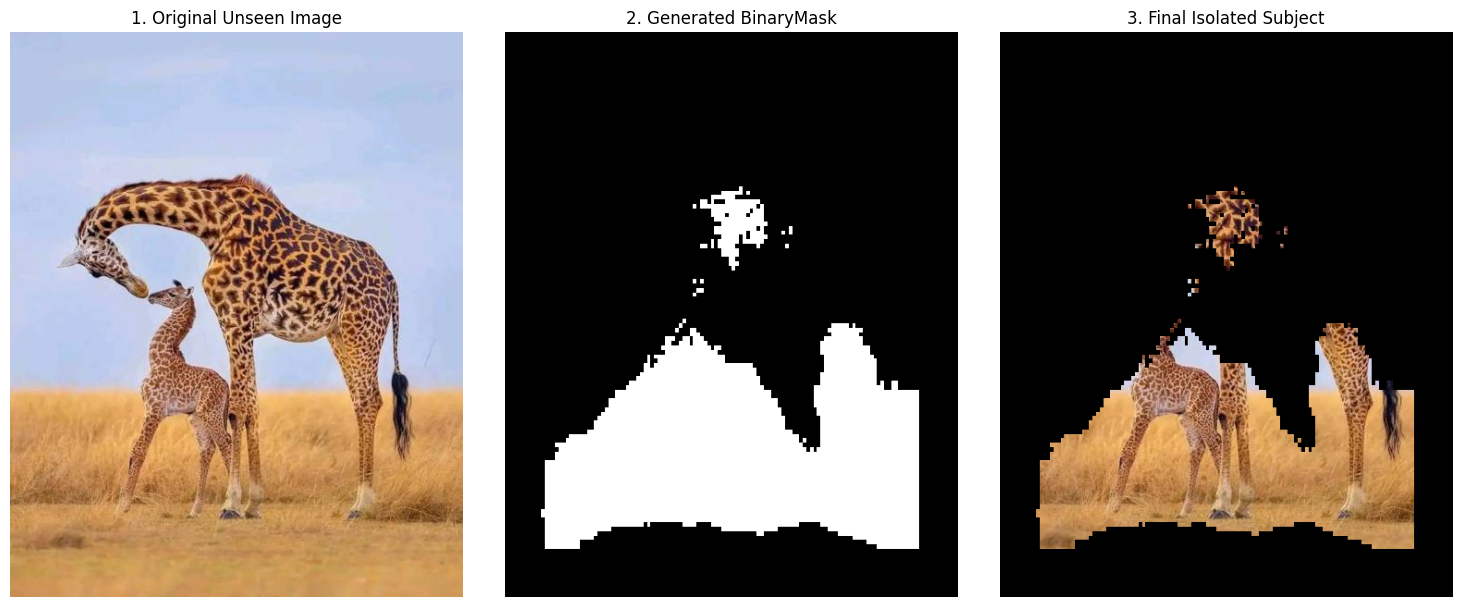

In [15]:
# Cell 13: Final Inference & Automation Pipeline (Week 6)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def isolate_subject(image_path, trained_model, output_filename="isolated_subject.jpg"):
    print(f"Processing new unseen image: {image_path}")
    
    # 1. Load the original high-resolution image
    original_img = cv2.imread(image_path)
    if original_img is None:
        print("❌ Error: Could not load image. Please double-check the file path.")
        return
        
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    original_h, original_w = original_img.shape[:2] # Save original dimensions
    
    # 2. Preprocess specifically for the model (resize to 128x128 and normalize)
    input_img = cv2.resize(original_img, (128, 128))
    input_img = input_img / 255.0
    input_img = np.expand_dims(input_img, axis=0) # Add the batch dimension: (1, 128, 128, 3)
    
    # 3. Generate the prediction mask
    pred_mask = trained_model.predict(input_img)[0] # Grab the first prediction
    
    # 4. Apply threshold to make it a strict binary mask (0 or 1)
    binary_mask = (pred_mask > 0.5).astype(np.uint8)
    
    # 5. Resize the mask BACK to the original image's high resolution!
    # We use INTER_NEAREST to keep the edges sharp
    full_size_mask = cv2.resize(binary_mask, (original_w, original_h), interpolation=cv2.INTER_NEAREST)
    
    # 6. Apply the mask to black out the background
    # We have to expand the mask to 3 channels so it matches the RGB image
    full_size_mask_3d = np.repeat(np.expand_dims(full_size_mask, axis=-1), 3, axis=-1)
    
    # Multiply the image by the mask! Background (0) becomes black, Subject (1) stays normal.
    final_output = original_img * full_size_mask_3d
    
    # 7. Save the final output to your computer
    final_output_bgr = cv2.cvtColor(final_output, cv2.COLOR_RGB2BGR) # Convert back to BGR for saving
    cv2.imwrite(output_filename, final_output_bgr)
    print(f"✅ Success! Subject isolated and saved as: {output_filename}")
    
    # 8. Visualize the magic for your presentation
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 3, 1)
    plt.title("1. Original Unseen Image")
    plt.imshow(original_img)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("2. Generated BinaryMask")
    plt.imshow(full_size_mask, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("3. Final Isolated Subject")
    plt.imshow(final_output)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# HOW TO USE IT:
# 1. Find ANY image on your computer (a person, animal, etc.)
# 2. Paste the path to that image below
# 3. Run the cell!
# ==========================================

# Example: (Uncomment the lines below and change the path to a real image on your PC)

# 1. Your exact local path to the test image
my_test_image = r'C:\Users\Sai\Downloads\giraffes.jpg'

# 2. Where to save the final result (we will save it right next to the original)
output_name = r'C:\Users\Sai\Downloads\final_isolated_giraffe.png'

# 3. Run the magic! 
# (Make sure 'advanced_model' matches the name of your trained model, or change it to 'model' if you are using the base one)
isolate_subject(image_path=my_test_image, trained_model=advanced_model, output_filename=output_name)

In [9]:
def isolate_subject(image_path, trained_model, output_filename="isolated_subject.jpg"):
    print(f"Processing new unseen image: {image_path}")
    
    # 1. Load the original high-resolution image
    original_img = cv2.imread(image_path)
    if original_img is None:
        print("❌ Error: Could not load image.")
        return
        
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    original_h, original_w = original_img.shape[:2] 
    
    # 2. Preprocess for the model
    input_img = cv2.resize(original_img, (128, 128))
    input_img = input_img / 255.0
    input_img = np.expand_dims(input_img, axis=0) 
    
    # 3. Generate the 128x128 prediction mask
    pred_mask = trained_model.predict(input_img)[0] 
    
    # 4. Standard threshold
    binary_mask = (pred_mask > 0.3).astype(np.uint8)
    
    # 5. THE NUCLEAR OPTION: Contour Filling
    # Find the outer boundary of the mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create a completely blank black mask
    filled_mask = np.zeros_like(binary_mask)
    
    # Draw the boundary and fill the entire inside with solid white!
    cv2.drawContours(filled_mask, contours, -1, (1), thickness=cv2.FILLED)
    
    # 6. Resize the patched mask smoothly
    smooth_mask = cv2.resize(filled_mask, (original_w, original_h), interpolation=cv2.INTER_CUBIC)
    
    # 7. Blur the edges slightly for a natural cutout
    blurred_mask = cv2.GaussianBlur(smooth_mask * 255, (21, 21), 0)
    final_mask_normalized = blurred_mask / 255.0
    
    # 8. Apply the mask to black out the background
    full_size_mask_3d = np.repeat(np.expand_dims(final_mask_normalized, axis=-1), 3, axis=-1)
    
    # Multiply and convert to integer pixels
    final_output = (original_img * full_size_mask_3d).astype(np.uint8)
    
    # 8. Save the final output
    final_output_bgr = cv2.cvtColor(final_output, cv2.COLOR_RGB2BGR) 
    cv2.imwrite(output_filename, final_output_bgr)
    print(f"✅ Success! Smooth subject isolated and saved as: {output_filename}")
    
    # 9. Visualize
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 3, 1)
    plt.title("1. Original Unseen Image")
    plt.imshow(original_img)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("2. Smoothed AI Mask")
    plt.imshow(final_mask_normalized, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("3. Final Isolated Subject")
    plt.imshow(final_output)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

Processing image using AI + GrabCut Edge Snapping: C:\Users\Sai\Downloads\giraffes.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Snapping mask to exact pixel edges... (this takes a few seconds)


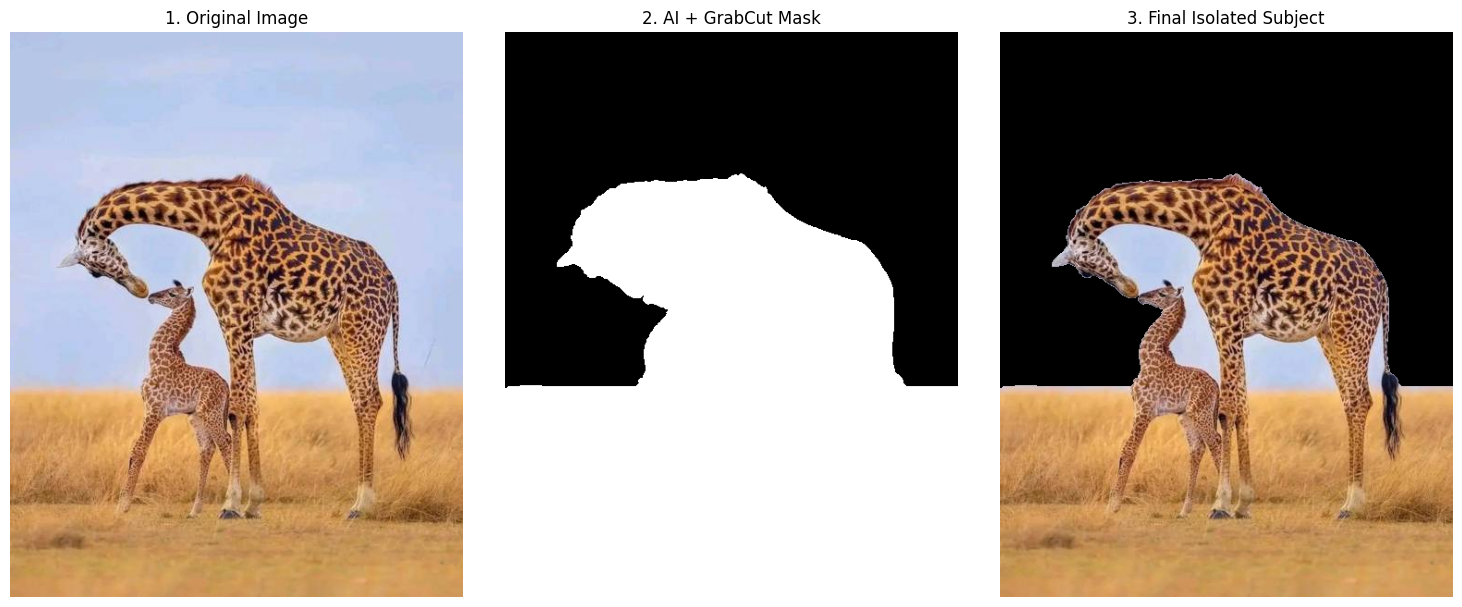

In [14]:
# Cell 13: Final Inference Pipeline (AI + GrabCut Edge Snapping)
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isolate_subject_custom(image_path, trained_model, output_filename="isolated_subject.jpg"):
    print(f"Processing image using AI + GrabCut Edge Snapping: {image_path}")
    
    # 1. Load the original high-resolution image
    original_img = cv2.imread(image_path)
    if original_img is None:
        print("❌ Error: Could not load image.")
        return
        
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    original_h, original_w = original_img.shape[:2] 
    
    # 2. Preprocess specifically for our 128x128 AI model
    input_img = cv2.resize(original_img, (128, 128))
    input_img = input_img / 255.0
    input_img = np.expand_dims(input_img, axis=0) 
    
    # 3. Generate the rough prediction mask from the AI
    pred_mask = trained_model.predict(input_img)[0].squeeze()
    
    # 4. Resize the raw AI mask to HD resolution
    full_mask = cv2.resize(pred_mask, (original_w, original_h), interpolation=cv2.INTER_LINEAR)
    
    # 5. THE ULTIMATE FIX: AI-Guided GrabCut!
    gc_mask = np.zeros((original_h, original_w), np.uint8)
    
    # Map AI confidence to GrabCut logic
    gc_mask[full_mask < 0.2] = cv2.GC_BGD       
    gc_mask[full_mask >= 0.2] = cv2.GC_PR_FGD   
    gc_mask[full_mask >= 0.8] = cv2.GC_FGD      
    
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)
    
    print("Snapping mask to exact pixel edges... (this takes a few seconds)")
    cv2.grabCut(original_img, gc_mask, None, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)
    
    # Extract the crisp binary mask from GrabCut
    raw_gc_mask = np.where((gc_mask == 2) | (gc_mask == 0), 0, 1).astype('uint8')
    
    # 6. POST-GRABCUT PATCHING: Fill the holes in the eyes and coat!
    # Find the crisp outer boundary that GrabCut just made
    contours, _ = cv2.findContours(raw_gc_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create a blank mask and fill the entire inside of that boundary solid white
    final_binary_mask = np.zeros_like(raw_gc_mask)
    cv2.drawContours(final_binary_mask, contours, -1, (1), thickness=cv2.FILLED)
    
    # 7. Apply the crisp, filled mask to black out the background
    full_size_mask_3d = np.repeat(np.expand_dims(final_binary_mask, axis=-1), 3, axis=-1)
    final_output = (original_img * full_size_mask_3d).astype(np.uint8)
    
    # 8. Visualize the results
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 3, 1)
    plt.title("1. Original Image")
    plt.imshow(original_img)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("2. AI + GrabCut Mask")
    plt.imshow(final_binary_mask, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("3. Final Isolated Subject")
    plt.imshow(final_output)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# TEST YOUR PORTRAIT HERE
# ==========================================
my_test_image = r'C:\Users\Sai\Downloads\giraffes.jpg'

# 2. Where to save the final result (we will save it right next to the original)
output_name = r'C:\Users\Sai\Downloads\final_isolated_giraffe.png'

# Make sure you are passing your trained model!
isolate_subject_custom(image_path=my_test_image, trained_model=advanced_model, output_filename=output_name)

Processing high-resolution image using U^2-Net: C:\Users\Sai\Downloads\public.jpg
✅ Success! Pro-level subject isolated and saved as: C:\Users\Sai\Downloads\final_isolated_public.png


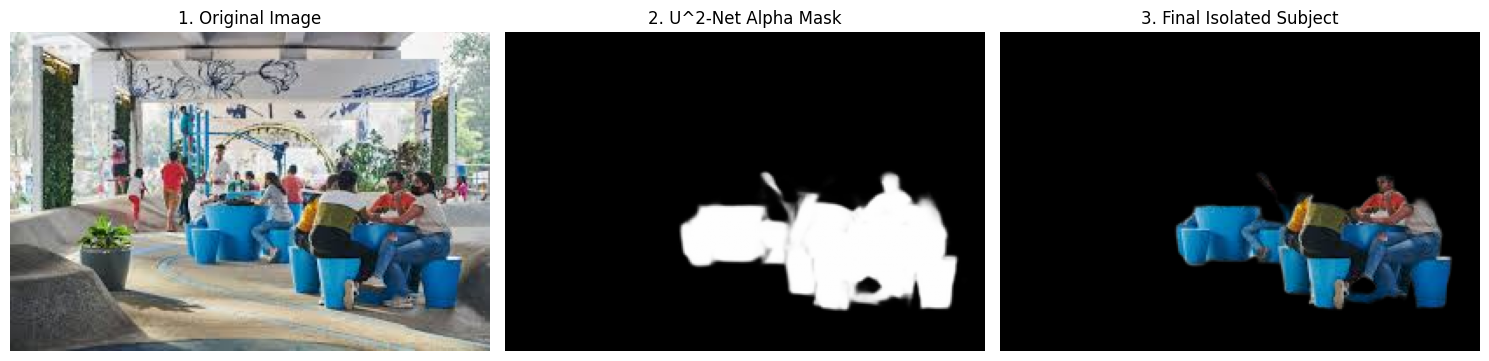

In [2]:
# Cell 13: PRO Inference Pipeline using U^2-Net (rembg)
import cv2
import numpy as np
import matplotlib.pyplot as plt
from rembg import remove

def isolate_subject_pro(image_path, output_filename="pro_isolated_subject.jpg"):
    print(f"Processing high-resolution image using U^2-Net: {image_path}")
    
    # 1. Load the original high-resolution image
    original_img = cv2.imread(image_path)
    if original_img is None:
        print("❌ Error: Could not load image. Check the file path.")
        return
        
    original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    # 2. THE MAGIC: Pass the image through U^2-Net to remove the background
    # This outputs an RGBA image (Red, Green, Blue, Alpha/Transparency)
    extracted_rgba = remove(original_rgb)
    
    # 3. Separate the colors (RGB) from the transparency mask (Alpha)
    subject_rgb = extracted_rgba[:, :, :3]
    alpha_mask = extracted_rgba[:, :, 3]
    
    # 4. Create a completely black background the same size as the image
    black_background = np.zeros_like(subject_rgb)
    
    # 5. Blend the subject onto the black background using the Alpha mask
    # This gives us those perfect, smooth hair edges!
    alpha_normalized = alpha_mask / 255.0
    alpha_3d = np.expand_dims(alpha_normalized, axis=-1)
    
    final_output = (subject_rgb * alpha_3d + black_background * (1 - alpha_3d)).astype(np.uint8)
    
    # 6. Save the final output to your computer
    final_output_bgr = cv2.cvtColor(final_output, cv2.COLOR_RGB2BGR) 
    cv2.imwrite(output_filename, final_output_bgr)
    print(f"✅ Success! Pro-level subject isolated and saved as: {output_filename}")
    
    # 7. Visualize the massive upgrade!
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 3, 1)
    plt.title("1. Original Image")
    plt.imshow(original_rgb)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("2. U^2-Net Alpha Mask")
    plt.imshow(alpha_mask, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("3. Final Isolated Subject")
    plt.imshow(final_output)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# TEST YOUR PORTRAIT HERE
# ==========================================
# Put the exact path to that studio portrait of yourself here:
my_test_image = r'C:\Users\Sai\Downloads\public.jpg'

# 2. Where to save the final result (we will save it right next to the original)
output_name = r'C:\Users\Sai\Downloads\final_isolated_public.png'

isolate_subject_pro(image_path=my_test_image, output_filename=output_name)